In [5]:
#Inicialización: borra todo y carga librerías (se pueden instalar fácilmente si no las tienen):
# install.packages("libreríaquequiero")

#Borra consola, variables y funciones definidas en el entorno Global
rm(list = setdiff(ls(), lsf.str()));
rm(list=lsf.str());
cat("\014")

#librerías, temas
suppressMessages(library("crayon")); suppressMessages(library("ggplot2"));
suppressMessages(library("gridExtra"));suppressMessages(library("latex2exp"))
library(xtable)
library(IRdisplay)
library(repr)

#opciones de ploteo ggplot2
temajuan3 <- theme(
    legend.title = element_text(size = 14),
    panel.background = element_rect(fill = "gray95"),
    legend.box = "horizontal",
    legend.direction = "horizontal",
    legend.key.height = unit(0.15,"snpc"),
    legend.key.width  = unit(0.15,"snpc"),
    axis.line = element_line(size = 0.5, lineend = "square"),
    axis.ticks = element_line(size = 1, colour = "black"),
    panel.border = element_rect(size = 1, fill = NA ),
    axis.title = element_text(size = 32),
    axis.text.x  = element_text(size = 28),
    axis.text.y = element_text(size = 28),
    legend.background = element_blank(),
    legend.position = c(0.3,0.8),
    legend.key = element_blank(),
    legend.text = element_text(size = 24),
    plot.title = element_text(size = 24)
    )
source("/home/juan/Documentos/Rfunj/temajuan2.R")
fig <- function(width, heigth){
 options(repr.plot.width = width, repr.plot.height = heigth)
 }
setwd("/home/juan/Documentos/Docencia/fexpi/")
fig(20,12)


Attaching package: ‘IRdisplay’


The following object is masked from ‘package:xtable’:

    display




# Distribución de Student

## El chiste

Ya vimos que podemos utilizar el teorema del límite central para calcular medias, pero pero pero:

*  No siempre converge fácil...y en teoría necesitamos una muestra no pequeña.

* La incerteza en la estimación de la media se hace a través de estimar $\sigma$ de la distribución del TLC a partir de la desviación estándar de la muestra...que para  tamaños de muestra pequeños no necesariamente funciona ni es estable ($\chi ^2 _\nu$ converge -se hace más ***picuda***- para muestras de gran tamaño...)

## El estadístico y la distribución de Student

El teorema de Don Estudiante dice que el estadístico: $$T = \dfrac{\overline{X} - \mu}{S\; /\; \sqrt{n}}$$
sigue una distribución de Student con $\nu = n-1$ de la forma:
$$f(t|\nu) = \dfrac{\Gamma\big[ \dfrac{(\nu + 1)}{2}  \big]  }{\sqrt{\pi\nu} \; \Gamma(\nu + 1)} \Bigg[ 1 + \dfrac{t^2}{\nu} \Bigg]^{-(\nu + 1)\, /\, 2}$$
  + Del estadístico diremos que está centrado: cada media muestral está restada de la media de la población...
    + La media del estadístico es cero: $\langle T \rangle = 0$ (no sesgado)
    + $Var(T) = \nu \; /\; (\nu - 2)$
  + De la distribución, lo de siempre: no hace falta saber la función $\Gamma$, sólo usar dstudent(); qstudent() y rstudent() genera la función densidad de prob, los cuantiles para las prob acumuladas que deseemos y números aleatorios de la distribución, respectivamente.


## Qué podría malir sal, si obtenemos incertezas de medias vía TLC?

Ya hablamos muchas veces del TLC: una media muestral de $n$ valores de una distribución con media $\mu$ y desviación estándar $\sigma$, vive en una distribución normal, con media $\mu$, y desviación estándar $\sigma / \sqrt{n} \approx s/\sqrt{n}$....(lo anterior nunca lo escribimos así, pero así funciona).

* Para que el TLC pueda ser usado, hay que usar un $n \rightarrow \infty$, pero nos conformamos con muestras que tengan un $n = 7,8,...$, depende de la distribución de origen que no podemos determinar.

* A veces no tenemos posibilidades de medir muchas veces, por:

    * La resolución temporal que necesitamos.
    
    * La dinámica ingobernable de nuestro sistema.
    
    * La escasez o rareza del fenómeno (ya dimos algunos ejemplos: rayos cósmicos, cosas que vienen del espacio, como los marcianos).

### La idea de usar el estadístico de Student es...

* Se pueden obtener cotas de confianza para la media de la distribución cuando tenemos un $n$ que es pequeño.

* Todo radica en que la distribución de Student es igual a una distribución normal cuando $\nu \rightarrow \infty$. Importante: es como el TLC, pero con colas más grandes cuando la muestra es pequeña, *that's all, folks*.

### Le damos una mirada a la distribución de Student y la comparamos con una normal.

In [6]:
x <- seq(-5,5,0.05); lx <- length(x); tag <- c("Cumple el TLC", "n = 2", "n = 3", "n = 4", "n = 8"); 
ds8 <- dt(x = x, df = 7); #Student con n = 8
ds4 <- dt(x = x, df = 3); #Student con n = 4
ds3 <- dt(x = x, df = 2); #Student con n = 3
ds2 <- dt(x = x, df = 1); #Student con n = 2
dn <- dnorm(x = x)
dts <- data.frame(x = rep(x, 5), d <- c(dn, ds2,ds3,ds4,ds8), n = rep(tag, each = lx))

In [7]:
gs <- ggplot(data = dts, aes(x = x, y = d, colour = n)) + 
#geom_line() + 
geom_line(aes(lty = n), lwd = 2) +
scale_colour_manual(values = c("Cumple el TLC" = "Deepskyblue4", "n = 2" = "Red", "n = 3" = "Red2", "n = 4" = "Red3", "n = 8" = "Red4" ) ) + 
scale_linetype_manual(values = c("Cumple el TLC" = 1, "n = 2" = 2, "n = 3" = 2, "n = 4" = 2, "n = 8" = 2 )) +
scale_x_continuous(breaks = seq(-5,5, 1), labels = seq(-5,5, 1)) +
temajuan3 + theme(legend.direction = "vertical", legend.position = c(0.15,0.7))

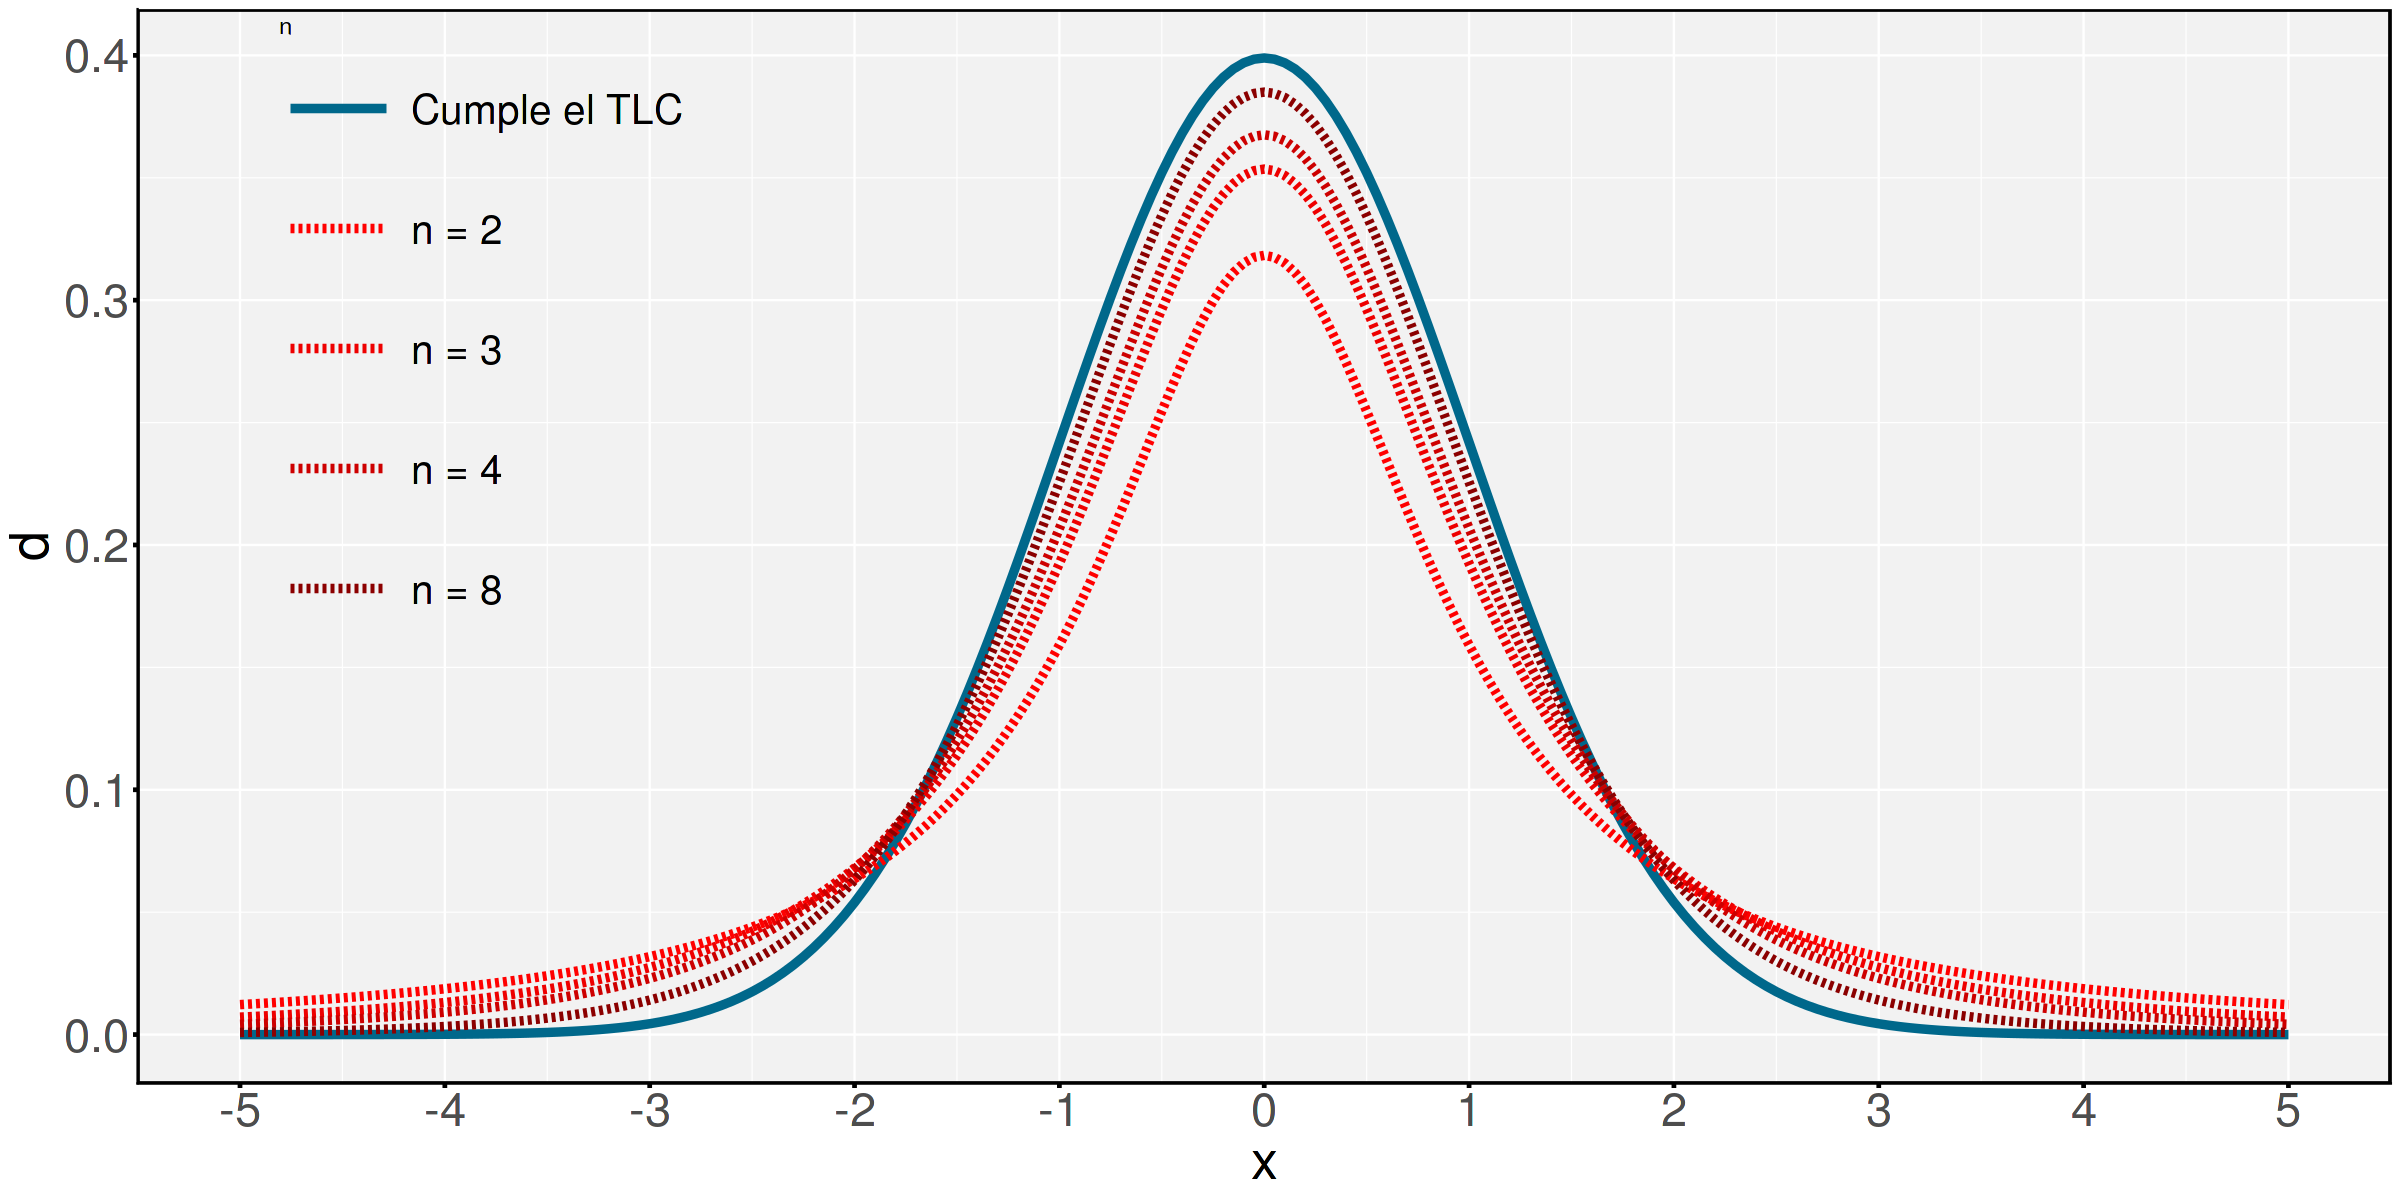

In [8]:
fig(20,10);show(gs)

Vemos que:
* Las colas de la distribución de Student son más grandes a medida que disminuímos el tamaño de la muestra.

* Lo anterior nos da intervalos mayores en las incertezas de la media, calculada a partir de muestras pequeñas.
 

## 1. El ejemplo clásico

Estimamos intervalos de confianza para una media, usando el TLC y Student.

***TLC***

In [9]:
set.seed(999111)
muestra <- rnorm(n = 5, mean = 10, sd = 1);
cat(bold("Medimos 5 veces una cantidad. Nuestros resultados son \n"))
cat(bold(muestra))

Medimos 5 veces una cantidad. Nuestros resultados son 
9.87645975350583 10.4645985238253 10.8760982054229 10.8368795918071 10.7719380326242

En lo anterior, $\mu = 10$. Pero si estimamos con el TLC y tres desviaciones (99.7% de nivel de confianza), lo que tenemos es:

In [70]:
mm <- mean(muestra); int <- sd(muestra)/sqrt(length(muestra))
cat(bold("La media estará entre: \n"))
cat(bold(mm - 3*int, " y ", mm + 3*int))
cat(bold("  con 99.7% de chances"))

La media estará entre: 
10.0048722787889  y  11.1255173640852  con 99.7% de chances

y claro, no está.

Como siempre, esto sólo tiene sentido si lo repetimos muchas veces y contamos cuántas veces entra dentro del intervalo y cuántas no.

**Tarea**: hacer un lindo for, para ver si se cumple el nivel de confianza...

***
***

***Student***

El chiste, sería el de siempre:

1. Proponemos el estadístico y su nivel de confianza, la cual metemos por media de los cuantiles de la distribución de Student.

2. Despejamos la media $\mu$ del estadístico, y estimamos el intervalo de confianza para el nivel de confianza seleccionado.

En lugar de escribir todo esto (que se los dejo para una hermosa tarea, incluyendo hacer lo mismo para el TLC), vamos a usar una función muy simple:

In [10]:
t.test(x = muestra , conf.level = 0.997) -> tteste
tteste$conf.int

[1]  9.363331 11.767058
attr(,"conf.level")
[1] 0.997

Lo anterior contiene a la media $\mu$. Importante notar que:

* El intervalo de confianza para ***el mismo nivel de confianza*** cambia mucho si usamos Student, porque la distribución tiene colas mucho más pesadas que la normal del TLC para $\nu = 5-1 = 4$.

* Sin embargo, en la repetición de este tipo de medidas, el nivel de confianza sólo va a poder ser obtenido para la distribución de Student.

## 2. El ejemplo *son lo mesmo*

In [87]:
muestra2 <- rnorm(mean = 10, sd = 1, n = 100) # "medimos" 100 veces

In [88]:
mm2 <- mean(muestra2);
int2 <- sd(muestra2)/sqrt(length(muestra2))

### TLC

In [89]:
cat(bold("La media estará entre: \n"))
cat(bold(mm2 - 3*int2, " y ", mm2 + 3*int2, "  con 99.7% de probabilidades"  ))

La media estará entre: 
9.66299857714298  y  10.25255576377   con 99.7% de probabilidades

### Test de Student

In [90]:
t.test(x = muestra2 , conf.level = 0.997) -> tteste
tteste$conf.int

[1]  9.658779 10.256775
attr(,"conf.level")
[1] 0.997

Con 100 medidas, el test de Student no se distingue del TLC.

**Tarea**: cambiar a 50, 25, 10 medidas.